# Goal: Create Extended Data Fig. 1 plots

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse

import session_info
session_info.show()

/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')`

In [2]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['pdf.fonttype'] = 42

save_dir='/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/Summary_plots/'

# Load the integrated T cell object

In [3]:
adata=sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/adata.h5ad')
adata

AnnData object with n_obs × n_vars = 3859644 × 11025
    obs: 'Compartment_prediction', 'Cross_tissue_broad', 'Cross_tissue_detailed', 'IR_VDJ_1_j_call', 'IR_VDJ_1_junction_aa', 'IR_VDJ_1_v_call', 'IR_VJ_1_j_call', 'IR_VJ_1_junction_aa', 'IR_VJ_1_v_call', 'Lindeboom_broad', 'Lindeboom_detailed', 'age', 'alternative_qc_status', 'author_annotation', 'barcode', 'batch_condition', 'cell_passed_qc', 'cell_type', 'dataset', 'dataset_id', 'disease', 'doi', 'donor', 'donor_id', 'doubletdetection_prediction', 'doubletdetection_score', 'filtered', 'group', 'infection_stage', 'infection_status', 'log1p_n_counts', 'log1p_n_genes', 'modalities', 'n_counts', 'n_counts_hb', 'n_counts_mito', 'n_counts_ribo', 'n_genes', 'obs_names_before_t_cells', 'organ', 'original_annotation', 'passed_qc', 'pathogen', 'percent_hb', 'percent_mito', 'percent_ribo', 'percent_top50', 'qc_status', 'reannotation', 'reannotation_index', 'sample', 'sample_id', 'scrublet_prediction', 'scrublet_score', 'sex', 'study', 'tissue'

In [4]:
# remove B cells
adata = adata[adata.obs['annotation_level_3'] != 'B']
adata.obs['annotation_level_3'] = adata.obs['annotation_level_3'].cat.remove_unused_categories()

/tmp/ipykernel_170894/3702848115.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['annotation_level_3'] = adata.obs['annotation_level_3'].cat.remove_unused_categories()


- Ext Data Fig. 1b

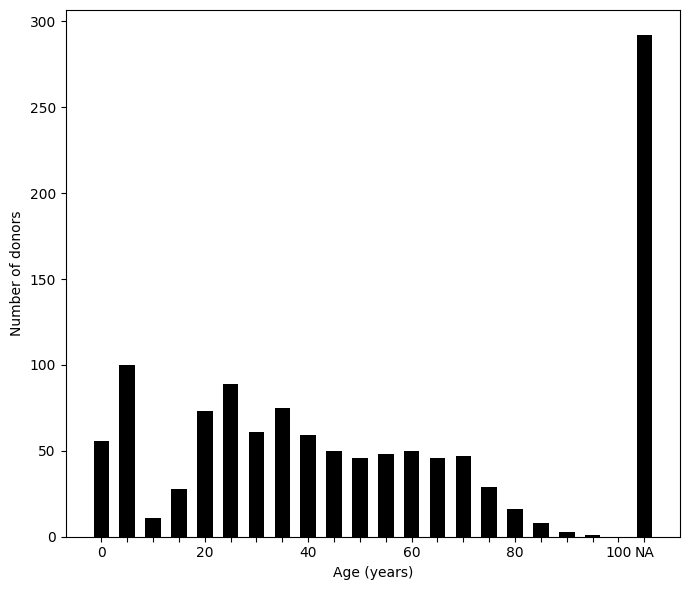

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

donor_df = adata.obs[['donor_id', 'age']].drop_duplicates()
donor_df['age'] = pd.to_numeric(donor_df['age'], errors='coerce')
donors_with_age = donor_df.dropna(subset=['age']).copy()
donors_missing_age = donor_df[donor_df['age'].isna()]

bins = range(0, int(donors_with_age['age'].max()) + 10, 5)
donors_with_age.loc[:, 'age_bin'] = pd.cut(donors_with_age['age'], bins=bins, right=False)
age_counts = donors_with_age['age_bin'].value_counts().sort_index()

age_counts = pd.concat([
    age_counts,
    pd.Series({'NA': len(donors_missing_age)})
])

plt.figure(figsize=(7,6))
ax = plt.gca()

bar_positions = range(len(age_counts))
ax.bar(bar_positions, age_counts.values, width=0.6, color="black")  # adjust width here

# add x-axis labels
xlabels = [
    f"{int(interval.left)}" if isinstance(interval, pd.Interval) and interval.left % 20 == 0
    else ""
    for interval in age_counts.index
]

# Replace last tick with "NA"
if "NA" in age_counts.index:
    xlabels[-1] = "NA"

ax.set_xticks(bar_positions)
ax.set_xticklabels(xlabels, rotation=0)

# Labels and style
ax.set_ylabel("Number of donors")
ax.set_xlabel("Age (years)")
ax.set_title("")
ax.grid(False)

plt.tight_layout()
#plt.savefig(save_dir+'Donor_age_distribution.pdf')
plt.show()

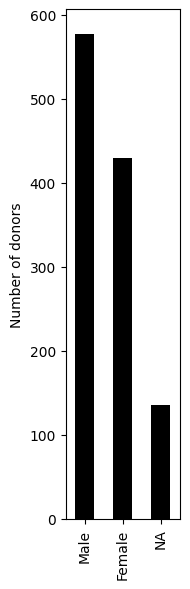

In [5]:
donor_df = adata.obs[['donor_id', 'sex']].drop_duplicates()

# Standardise/harmonise sex labels
donor_df['sex'] = donor_df['sex'].astype(str).str.strip().str.lower()
donor_df['sex'] = donor_df['sex'].replace({
    'male': 'Male',
    'm': 'Male',
    'female': 'Female',
    'f': 'Female',
    'nan': 'NA',
    'none': 'NA'
})

# Replace actual NaN values with "NA"
donor_df['sex'] = donor_df['sex'].fillna('NA')

# Count donors per sex category
sex_counts = donor_df['sex'].value_counts().reindex(['Male', 'Female', 'NA'], fill_value=0)

plt.figure(figsize=(2,6))
ax = sex_counts.plot(kind='bar', color='black')

ax.set_xticklabels(sex_counts.index, rotation=90)
ax.set_ylabel("Number of donors")
ax.set_xlabel("")
ax.set_title("")

# Remove grid
ax.grid(False)

plt.tight_layout()
#plt.savefig(save_dir+'Donor_sex_distribution.pdf')
plt.show()

- Ext Data Fig. 1c

In [14]:
# Load the updated T cell annotations
annotation_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_annotation.csv', index_col=0)


annot_cols=['annotation_level_1','annotation_level_2','annotation_level_3','annotation_level_4']
for annotation in annot_cols:
    adata.obs[annotation]=adata.obs[annotation].astype(str)
    adata.obs.loc[annotation_df.index, annotation] = annotation_df[annotation].values

/tmp/ipykernel_208090/2067266209.py:2: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  annotation_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_annotation.csv', index_col=0)


In [7]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 10)

In [6]:
UMAP = np.load('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/UMAPs/all_T_cells_umap_neighbors_30_mindist_13_spread_1.npy')
adata.obsm["X_umap"] = UMAP

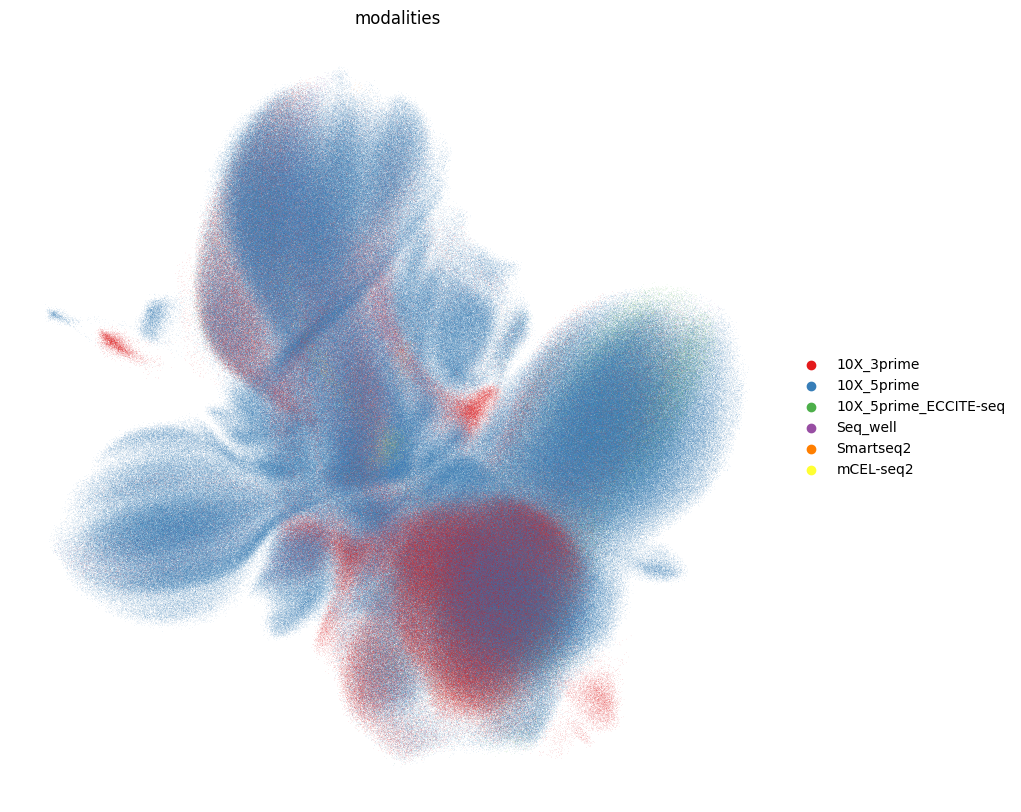

In [15]:
import seaborn as sns

palette = sns.color_palette("Set1", n_colors=6)
custom_palette = list(palette)

sc.pl.umap(adata, color='modalities', palette=custom_palette, size=0.2, frameon=False, show=False)

#plt.savefig(save_dir+'Umap_modalities.pdf')
plt.show()

/tmp/ipykernel_208090/3355453766.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df = df.groupby(['annotation_level_1', 'modalities']).size().reset_index(name='cell_count')


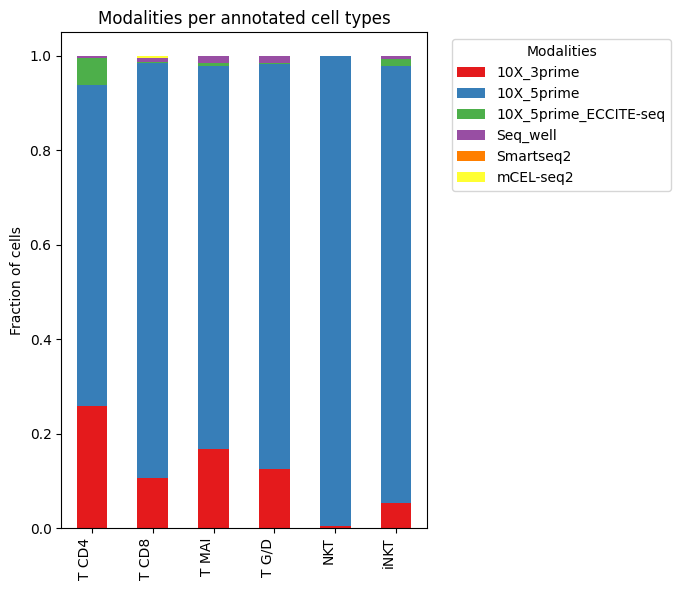

In [16]:
custom_order=['T CD4','T CD8', 'T MAI', 'T G/D', 'NKT', 'iNKT']

df = adata.obs[['annotation_level_1', 'modalities']].copy()

# Remove missing values if any
#df = df.dropna(subset=['annotation_level_2', 'tissue'])

# Count cells per combination
count_df = df.groupby(['annotation_level_1', 'modalities']).size().reset_index(name='cell_count')

# Pivot to have tissues as columns
pivot_df = count_df.pivot(index='annotation_level_1', columns='modalities', values='cell_count').fillna(0)

# Convert counts to relative frequencies per cell type
rel_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Reindex rows according to custom order
rel_df = rel_df.reindex(custom_order)

# Remove gridlines
ax.grid(False)

modalities = rel_df.columns.tolist()

# Generate Set1 palette with enough colors
palette = sns.color_palette("Set1", n_colors=len(modalities))

# Create a dictionary mapping modality -> color
modality_colors = dict(zip(modalities, palette))

# Plot stacked bar using the colors
ax=rel_df.plot(kind='bar', stacked=True, figsize=(7,6), color=[modality_colors[m] for m in rel_df.columns])
ax.grid(False)

plt.ylabel("Fraction of cells")
plt.xlabel("")
plt.title("Modalities per annotated cell types")
plt.xticks(rotation=90, ha='right')
plt.legend(title='Modalities', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
#plt.savefig(save_dir+'Modalities_level_1.pdf')
plt.show()

- Ext Data Fig. 1d

In [17]:
adata.obs['pathogen']=adata.obs['pathogen'].cat.add_categories('Bacterial_sepsis')

mask = (adata.obs['author_year_pathogen'] == 'Reyes_2020_Bacterial_Sepsis') & (adata.obs['pathogen_type']=='Bacterium')
adata.obs.loc[mask, 'pathogen'] = 'Bacterial_sepsis'

In [18]:
adata.obs['pathogen']=adata.obs['pathogen'].cat.add_categories('Other Control')

mask = (adata.obs['author_year_pathogen'] == 'Reyes_2020_Bacterial_Sepsis') & (adata.obs['pathogen_type']=='nan')
adata.obs.loc[mask, 'pathogen'] = 'Other Control'

In [19]:
mask = (adata.obs['author_year_pathogen'] == 'Liu_2021_SARS-CoV-2') & (adata.obs['pathogen_type']=='nan')
adata.obs.loc[mask, 'pathogen_type'] = 'Healthy'

In [20]:
adata.obs['pathogen_type']=adata.obs['pathogen_type'].cat.add_categories('Other Control')

adata.obs.loc[
    adata.obs['pathogen_type'] == 'nan',
    'pathogen_type'
] = 'Other Control'

adata.obs['pathogen_type']=adata.obs['pathogen_type'].cat.remove_unused_categories()

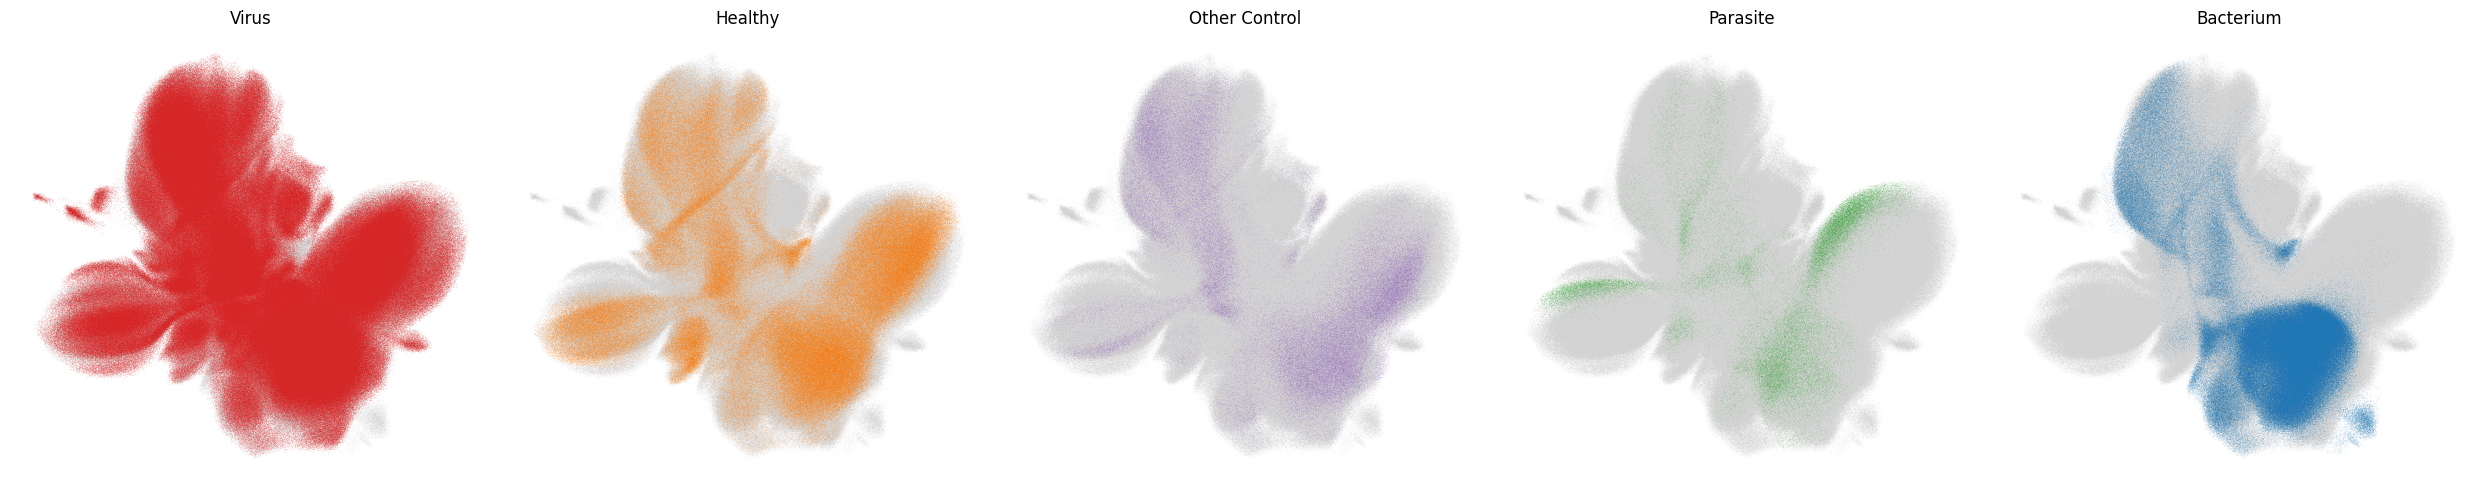

In [28]:
pathogens = adata.obs['pathogen_type'].unique().tolist()

# Set up subplot grid
n_cols = 5
n_rows = int(np.ceil(len(pathogens) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

# Loop through each pathogen
for i, each in enumerate(pathogens):
    ax = axes[i]
    sc.pl.umap(
        adata,
        color='pathogen_type',
        groups=[each],      # highlight just one pathogen
        frameon=False,
        ax=ax,
        show=False,
        title=each,
        legend_loc=None,
        size=0.2
    )

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

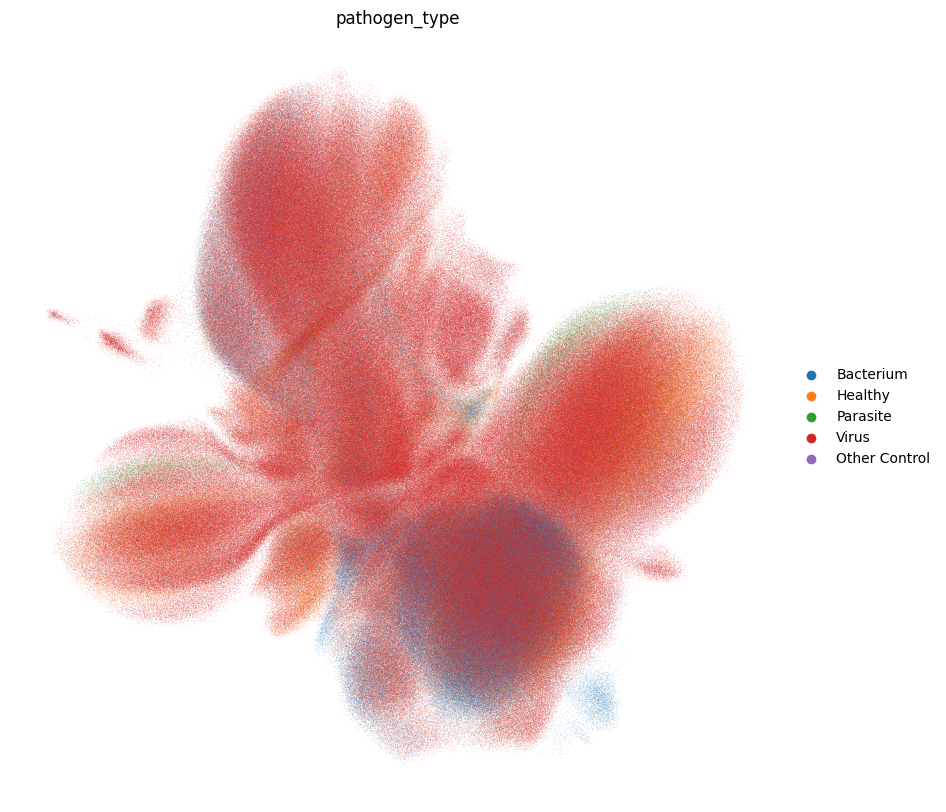

In [30]:
sc.pl.umap(adata, color='pathogen_type', size=0.2, frameon=False, show=False)

#plt.savefig(save_dir+'Umap_pathogen_type.pdf')
plt.show()

/tmp/ipykernel_208090/4199445907.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df = df.groupby(['annotation_level_1', 'pathogen_type']).size().reset_index(name='cell_count')


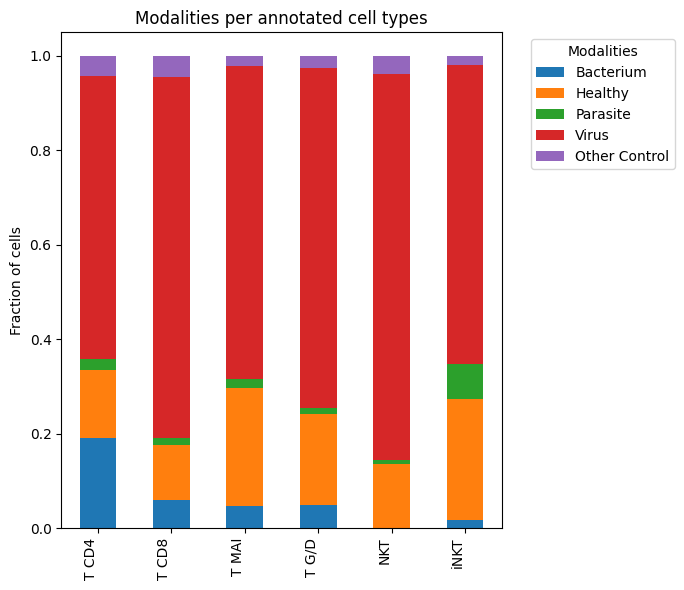

In [35]:
import seaborn as sns

custom_order=['T CD4','T CD8','T MAI','T G/D','NKT','iNKT']

df = adata.obs[['annotation_level_1', 'pathogen_type']].copy()

# Remove missing values if any
#df = df.dropna(subset=['annotation_level_2', 'tissue'])

# Count cells per combination
count_df = df.groupby(['annotation_level_1', 'pathogen_type']).size().reset_index(name='cell_count')

# Pivot to have tissues as columns
pivot_df = count_df.pivot(index='annotation_level_1', columns='pathogen_type', values='cell_count').fillna(0)

# Convert counts to relative frequencies per cell type
rel_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Reindex rows according to custom order
rel_df = rel_df.reindex(custom_order)

# Remove gridlines
fig, ax = plt.subplots(figsize=(7, 6))
ax.grid(False)
rel_df.plot(kind='bar', stacked=True, ax=ax)  # ← use existing ax, drop figsize here
ax.grid(False)
plt.ylabel("Fraction of cells")
plt.xlabel("")
plt.title("Modalities per annotated cell types")
plt.xticks(rotation=90, ha='right')
plt.legend(title='Modalities', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
#plt.savefig(save_dir+'pathogen_type_level_1.pdf')
plt.show()